# 11 - CLIP Breed Prediction per tutti i cani

Questo notebook aggiunge una nuova estensione senza modificare i notebook precedenti.

Obiettivo:

- usare **CLIP** invece di ResNet50;
- stimare le razze visivamente più compatibili per **tutti i cani**;
- usare **tutte le foto disponibili** per ogni cane;
- confrontare le immagini con testi del tipo `a photo of a Chihuahua dog`;
- salvare il CSV finale:

```text
../data/results/clip_breed_predictions_all_dogs.csv
```

Le razze CLIP sono una stima visuale aggiuntiva e non sostituiscono le razze ufficiali del dataset.


## 1. Import

In [1]:
from pathlib import Path
from collections import defaultdict

import pandas as pd
import numpy as np
import torch
from PIL import Image
from tqdm.auto import tqdm

from transformers import CLIPProcessor, CLIPModel


## 2. Caricamento dataset e percorsi

In [2]:
dogs = pd.read_csv("../data/processed/dogs_clean.csv")

images_dir = Path("../data/raw/train_images")
results_dir = Path("../data/results")
results_dir.mkdir(parents=True, exist_ok=True)

output_path = results_dir / "clip_breed_predictions_all_dogs.csv"

print("Dataset cani:", dogs.shape)
print("Cartella immagini esiste:", images_dir.exists())
print("Output:", output_path)


Dataset cani: (8132, 32)
Cartella immagini esiste: True
Output: ..\data\results\clip_breed_predictions_all_dogs.csv


## 3. Lista razze canine

In [3]:
dog_breeds = [
    "Affenpinscher", "Afghan Hound", "Airedale Terrier", "Akita",
    "Alaskan Malamute", "American Bulldog", "American Cocker Spaniel",
    "American Eskimo Dog", "American Foxhound", "American Pit Bull Terrier",
    "American Staffordshire Terrier", "Anatolian Shepherd Dog",
    "Australian Cattle Dog", "Australian Kelpie", "Australian Shepherd",
    "Australian Terrier", "Basenji", "Basset Hound", "Beagle",
    "Bearded Collie", "Beauceron", "Bedlington Terrier", "Belgian Malinois",
    "Belgian Sheepdog", "Bernese Mountain Dog", "Bichon Frise",
    "Black and Tan Coonhound", "Bloodhound", "Border Collie",
    "Border Terrier", "Borzoi", "Boston Terrier", "Boxer",
    "Brittany", "Brussels Griffon", "Bull Terrier", "Bulldog",
    "Bullmastiff", "Cairn Terrier", "Canaan Dog", "Cane Corso",
    "Cardigan Welsh Corgi", "Cavalier King Charles Spaniel",
    "Chesapeake Bay Retriever", "Chihuahua", "Chinese Crested",
    "Chinese Shar-Pei", "Chow Chow", "Clumber Spaniel", "Cocker Spaniel",
    "Collie", "Dachshund", "Dalmatian", "Doberman Pinscher",
    "Dogo Argentino", "Dogue de Bordeaux", "English Cocker Spaniel",
    "English Foxhound", "English Setter", "English Springer Spaniel",
    "English Toy Spaniel", "Finnish Spitz", "Flat-Coated Retriever",
    "French Bulldog", "German Pinscher", "German Shepherd Dog",
    "German Shorthaired Pointer", "German Wirehaired Pointer",
    "Giant Schnauzer", "Golden Retriever", "Gordon Setter",
    "Great Dane", "Great Pyrenees", "Greyhound", "Havanese",
    "Ibizan Hound", "Irish Setter", "Irish Terrier", "Irish Wolfhound",
    "Italian Greyhound", "Jack Russell Terrier", "Japanese Chin",
    "Keeshond", "Kerry Blue Terrier", "Komondor", "Labrador Retriever",
    "Lakeland Terrier", "Lhasa Apso", "Maltese", "Manchester Terrier",
    "Mastiff", "Miniature Pinscher", "Miniature Schnauzer",
    "Neapolitan Mastiff", "Newfoundland", "Norfolk Terrier",
    "Norwegian Elkhound", "Norwich Terrier", "Old English Sheepdog",
    "Papillon", "Pekingese", "Pembroke Welsh Corgi", "Pharaoh Hound",
    "Pointer", "Pomeranian", "Poodle", "Portuguese Water Dog", "Pug",
    "Rat Terrier", "Rhodesian Ridgeback", "Rottweiler", "Saint Bernard",
    "Saluki", "Samoyed", "Schipperke", "Scottish Terrier",
    "Shetland Sheepdog", "Shiba Inu", "Shih Tzu", "Siberian Husky",
    "Smooth Fox Terrier", "Staffordshire Bull Terrier",
    "Standard Schnauzer", "Tibetan Mastiff", "Toy Fox Terrier",
    "Vizsla", "Weimaraner", "Welsh Springer Spaniel", "Welsh Terrier",
    "West Highland White Terrier", "Whippet", "Wire Fox Terrier",
    "Yorkshire Terrier"
]

# Aggiungo anche eventuali razze presenti nel dataset PetFinder.
dataset_breeds = set()

for col in ["breed1_label", "breed2_label"]:
    if col in dogs.columns:
        dataset_breeds.update(
            dogs[col]
            .dropna()
            .astype(str)
            .str.strip()
            .tolist()
        )

dataset_breeds = {
    b for b in dataset_breeds
    if b and b.lower() not in ["nan", "none", "mixed breed", "unknown"]
}

dog_breeds = sorted(set(dog_breeds).union(dataset_breeds))

print("Numero razze candidate:", len(dog_breeds))
dog_breeds[:20]


Numero razze candidate: 188


['Affenpinscher',
 'Afghan Hound',
 'Airedale Terrier',
 'Akbash',
 'Akita',
 'Alaskan Malamute',
 'American Bulldog',
 'American Cocker Spaniel',
 'American Eskimo Dog',
 'American Foxhound',
 'American Pit Bull Terrier',
 'American Staffordshire Terrier',
 'American Water Spaniel',
 'Anatolian Shepherd Dog',
 'Australian Cattle Dog',
 'Australian Cattle Dog/Blue Heeler',
 'Australian Kelpie',
 'Australian Shepherd',
 'Australian Terrier',
 'Basenji']

## 4. Caricamento CLIP

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(model_name).to(device)
clip_processor = CLIPProcessor.from_pretrained(model_name)

clip_model.eval()

print("Modello:", model_name)
print("Device:", device)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Modello: openai/clip-vit-base-patch32
Device: cpu


## 5. Embedding testuali delle razze

In [5]:
breed_prompts = [f"a photo of a {breed} dog" for breed in dog_breeds]

with torch.no_grad():
    text_inputs = clip_processor(
        text=breed_prompts,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    # Versione compatibile anche con ambienti in cui get_text_features()
    # restituisce un oggetto e non direttamente un tensore.
    text_outputs = clip_model.text_model(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"]
    )

    text_features = clip_model.text_projection(text_outputs.pooler_output)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Text features:", text_features.shape)


Text features: torch.Size([188, 512])


## 6. Funzioni CLIP

In [6]:
def get_image_paths_for_pet(pet_id):
    pet_id = str(pet_id)

    paths = []
    paths.extend(sorted(images_dir.glob(f"{pet_id}-*.jpg")))
    paths.extend(sorted(images_dir.glob(f"{pet_id}-*.jpeg")))
    paths.extend(sorted(images_dir.glob(f"{pet_id}-*.png")))

    return sorted(set(paths))


def get_image_feature(image_path):
    image = Image.open(image_path).convert("RGB")

    with torch.no_grad():
        image_inputs = clip_processor(
            images=image,
            return_tensors="pt"
        ).to(device)

        # Versione compatibile anche con ambienti in cui get_image_features()
        # non restituisce direttamente un tensore.
        image_outputs = clip_model.vision_model(
            pixel_values=image_inputs["pixel_values"]
        )

        image_features = clip_model.visual_projection(image_outputs.pooler_output)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    return image_features


def predict_breeds_for_image(image_path, top_k=5):
    image_features = get_image_feature(image_path)

    with torch.no_grad():
        similarities = (image_features @ text_features.T).squeeze(0)

        # Softmax: trasforma le similarità in punteggi confrontabili tra razze.
        probs = similarities.softmax(dim=0)

        top = torch.topk(probs, k=top_k)

    results = []

    for score, idx in zip(top.values.cpu().numpy(), top.indices.cpu().numpy()):
        results.append({
            "breed": dog_breeds[int(idx)],
            "score": float(score)
        })

    return results


def predict_breeds_for_pet_all_images(pet_id, top_k=5):
    image_paths = get_image_paths_for_pet(pet_id)

    if len(image_paths) == 0:
        return [], 0

    image_features_list = []

    for image_path in image_paths:
        try:
            image_features = get_image_feature(image_path)
            image_features_list.append(image_features)
        except Exception as e:
            print("Errore immagine:", image_path, "|", e)

    if len(image_features_list) == 0:
        return [], 0

    # Media degli embedding immagine: usa tutte le foto del cane.
    mean_image_features = torch.stack(image_features_list).mean(dim=0)
    mean_image_features = mean_image_features / mean_image_features.norm(dim=-1, keepdim=True)

    with torch.no_grad():
        similarities = (mean_image_features @ text_features.T).squeeze(0)
        probs = similarities.softmax(dim=0)
        top = torch.topk(probs, k=top_k)

    results = []

    for score, idx in zip(top.values.cpu().numpy(), top.indices.cpu().numpy()):
        results.append({
            "breed": dog_breeds[int(idx)],
            "score": float(score)
        })

    return results, len(image_features_list)


## 7. Test su un cane

PetID esempio: 3422e4906
Numero immagini usate: 7


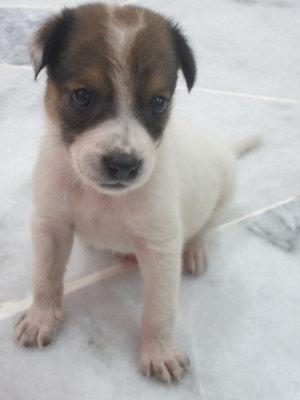

Immagini effettivamente usate: 7


,breed,score
0,Jack Russell Terrier (Parson Russell Terrier),0.005746
1,Jack Russell Terrier,0.005695
2,Rat Terrier,0.005599
3,Terrier,0.005592
4,Cardigan Welsh Corgi,0.005584


In [7]:
example_pet_id = None

for pet_id in dogs["PetID"].head(200):
    paths = get_image_paths_for_pet(pet_id)
    if len(paths) > 0:
        example_pet_id = pet_id
        break

print("PetID esempio:", example_pet_id)

if example_pet_id is not None:
    example_paths = get_image_paths_for_pet(example_pet_id)
    print("Numero immagini usate:", len(example_paths))
    display(Image.open(example_paths[0]).convert("RGB"))

    preds, num_images_used = predict_breeds_for_pet_all_images(example_pet_id, top_k=5)
    print("Immagini effettivamente usate:", num_images_used)
    display(pd.DataFrame(preds))


## 8. Predizione CLIP per tutti i cani

In [8]:
rows = []
top_k = 5

for _, dog in tqdm(dogs.iterrows(), total=len(dogs)):
    pet_id = dog["PetID"]

    aggregated, num_images_used = predict_breeds_for_pet_all_images(
        pet_id,
        top_k=top_k
    )

    row = {
        "PetID": pet_id,
        "Name": dog.get("Name", ""),
        "breed1_label": dog.get("breed1_label", ""),
        "breed2_label": dog.get("breed2_label", ""),
        "num_images_used": num_images_used
    }

    for i in range(top_k):
        if i < len(aggregated):
            row[f"clip_breed_{i+1}"] = aggregated[i]["breed"]
            row[f"clip_breed_{i+1}_score"] = aggregated[i]["score"]
        else:
            row[f"clip_breed_{i+1}"] = ""
            row[f"clip_breed_{i+1}_score"] = 0.0

    rows.append(row)

clip_breed_predictions = pd.DataFrame(rows)
clip_breed_predictions.head()i


  0%|          | 0/8132 [00:00<?, ?it/s]

,PetID,Name,breed1_label,breed2_label,num_images_used,clip_breed_1,clip_breed_1_score,clip_breed_2,clip_breed_2_score,clip_breed_3,clip_breed_3_score,clip_breed_4,clip_breed_4_score,clip_breed_5,clip_breed_5_score
0,3422e4906,Brisco,Mixed Breed,NaN,7,Jack Russell Terrier (Parson Russell Terrier),0.005746,Jack Russell Terrier,0.005695,Rat Terrier,0.005599,Terrier,0.005592,Cardigan Welsh Corgi,0.005584
1,5842f1ff5,Miko,Mixed Breed,NaN,8,Lowchen,0.005618,Kai Dog,0.005590,Akbash,0.005585,Munsterlander,0.005584,Australian Kelpie,0.005572
2,850a43f90,Hunter,Mixed Breed,NaN,3,Black Labrador Retriever,0.005684,Labrador Retriever,0.005674,Schipperke,0.005640,Affenpinscher,0.005566,Chocolate Labrador Retriever,0.005557
3,97aa9eeac,Siu Pak & Her 6 Puppies,Mixed Breed,NaN,9,Kai Dog,0.005568,Jack Russell Terrier (Parson Russell Terrier),0.005568,Akbash,0.005551,Lowchen,0.005540,Jack Russell Terrier,0.005535
4,8b693ca84,Bear,Mixed Breed,NaN,7,Jack Russell Terrier (Parson Russell Terrier),0.005749,Jack Russell Terrier,0.005684,Rat Terrier,0.005648,Toy Fox Terrier,0.005589,Akbash,0.005584


## 9. Salvataggio CSV

In [9]:
clip_breed_predictions.to_csv(output_path, index=False)

print("CSV salvato in:", output_path)
print("Dimensione:", clip_breed_predictions.shape)

clip_breed_predictions.head(20)


CSV salvato in: ..\data\results\clip_breed_predictions_all_dogs.csv
Dimensione: (8132, 15)


,PetID,Name,breed1_label,breed2_label,num_images_used,clip_breed_1,clip_breed_1_score,clip_breed_2,clip_breed_2_score,clip_breed_3,clip_breed_3_score,clip_breed_4,clip_breed_4_score,clip_breed_5,clip_breed_5_score
0,3422e4906,Brisco,Mixed Breed,NaN,7,Jack Russell Terrier (Parson Russell Terrier),0.005746,Jack Russell Terrier,0.005695,Rat Terrier,0.005599,Terrier,0.005592,Cardigan Welsh Corgi,0.005584
1,5842f1ff5,Miko,Mixed Breed,NaN,8,Lowchen,0.005618,Kai Dog,0.005590,Akbash,0.005585,Munsterlander,0.005584,Australian Kelpie,0.005572
2,850a43f90,Hunter,Mixed Breed,NaN,3,Black Labrador Retriever,0.005684,Labrador Retriever,0.005674,Schipperke,0.005640,Affenpinscher,0.005566,Chocolate Labrador Retriever,0.005557
3,97aa9eeac,Siu Pak & Her 6 Puppies,Mixed Breed,NaN,9,Kai Dog,0.005568,Jack Russell Terrier (Parson Russell Terrier),0.005568,Akbash,0.005551,Lowchen,0.005540,Jack Russell Terrier,0.005535
4,8b693ca84,Bear,Mixed Breed,NaN,7,Jack Russell Terrier (Parson Russell Terrier),0.005749,Jack Russell Terrier,0.005684,Rat Terrier,0.005648,Toy Fox Terrier,0.005589,Akbash,0.005584
5,aaedd873d,Peanut,Mixed Breed,NaN,1,Black Mouth Cur,0.005694,Yellow Labrador Retriever,0.005642,Akbash,0.005575,Golden Retriever,0.005569,Kai Dog,0.005568
6,c02be41e6,Lost Dog,Mixed Breed,NaN,2,Yellow Labrador Retriever,0.005664,Labrador Retriever,0.005662,Akbash,0.005646,Kai Dog,0.005644,Anatolian Shepherd Dog,0.005630
7,1fd342e17,Max,Terrier,Shih Tzu,2,Glen of Imaal Terrier,0.005750,Poodle,0.005713,Bichon Frise,0.005703,Lowchen,0.005698,Maltese,0.005687
8,f9d07d5fa,Blackie,Mixed Breed,Mixed Breed,2,Dutch Shepherd,0.005788,Belgian Shepherd Malinois,0.005725,Belgian Malinois,0.005721,Lowchen,0.005674,Belgian Shepherd Laekenois,0.005660
9,1c92ce464,Beauty,Mixed Breed,NaN,8,Labrador Retriever,0.005764,Black Labrador Retriever,0.005755,Schipperke,0.005663,Retriever,0.005615,Kai Dog,0.005607


## 10. Controlli finali

In [10]:
print("Cani senza immagini:", (clip_breed_predictions["num_images_used"] == 0).sum())

comparison_cols = [
    "PetID", "Name", "breed1_label", "breed2_label",
    "clip_breed_1", "clip_breed_1_score",
    "clip_breed_2", "clip_breed_2_score",
    "clip_breed_3", "clip_breed_3_score",
    "num_images_used"
]

clip_breed_predictions[comparison_cols].head(30)


Cani senza immagini: 194


,PetID,Name,breed1_label,breed2_label,clip_breed_1,clip_breed_1_score,clip_breed_2,clip_breed_2_score,clip_breed_3,clip_breed_3_score,num_images_used
0,3422e4906,Brisco,Mixed Breed,NaN,Jack Russell Terrier (Parson Russell Terrier),0.005746,Jack Russell Terrier,0.005695,Rat Terrier,0.005599,7
1,5842f1ff5,Miko,Mixed Breed,NaN,Lowchen,0.005618,Kai Dog,0.005590,Akbash,0.005585,8
2,850a43f90,Hunter,Mixed Breed,NaN,Black Labrador Retriever,0.005684,Labrador Retriever,0.005674,Schipperke,0.005640,3
3,97aa9eeac,Siu Pak & Her 6 Puppies,Mixed Breed,NaN,Kai Dog,0.005568,Jack Russell Terrier (Parson Russell Terrier),0.005568,Akbash,0.005551,9
4,8b693ca84,Bear,Mixed Breed,NaN,Jack Russell Terrier (Parson Russell Terrier),0.005749,Jack Russell Terrier,0.005684,Rat Terrier,0.005648,7
5,aaedd873d,Peanut,Mixed Breed,NaN,Black Mouth Cur,0.005694,Yellow Labrador Retriever,0.005642,Akbash,0.005575,1
6,c02be41e6,Lost Dog,Mixed Breed,NaN,Yellow Labrador Retriever,0.005664,Labrador Retriever,0.005662,Akbash,0.005646,2
7,1fd342e17,Max,Terrier,Shih Tzu,Glen of Imaal Terrier,0.005750,Poodle,0.005713,Bichon Frise,0.005703,2
8,f9d07d5fa,Blackie,Mixed Breed,Mixed Breed,Dutch Shepherd,0.005788,Belgian Shepherd Malinois,0.005725,Belgian Malinois,0.005721,2
9,1c92ce464,Beauty,Mixed Breed,NaN,Labrador Retriever,0.005764,Black Labrador Retriever,0.005755,Schipperke,0.005663,8


## Conclusione

Questo notebook crea il nuovo file:

```text
data/results/clip_breed_predictions_all_dogs.csv
```

Differenza importante rispetto al notebook precedente con ResNet50:

- ResNet50 classificava l'immagine in classi predefinite;
- CLIP confronta direttamente immagine e testo;
- per ogni cane vengono usate tutte le foto disponibili;
- gli embedding delle foto vengono mediati e poi confrontati con le razze candidate.

Il CSV prodotto potrà essere usato nel notebook successivo per integrare CLIP nel sistema di matching.
